In [1]:
project_title = "Tourism and Economic Indicators Analysis"
project_objective = """
This project explores the relationship between tourism activity and selected economic indicators 
across countries and years.The analysis focuses on:
1. Trends over time
2. Country-level comparisons
3. Relationships between tourism and economic variables
4. SQl-style querying and summary outputs
"""
print(project_title)
print(project_objective)

Tourism and Economic Indicators Analysis

This project explores the relationship between tourism activity and selected economic indicators 
across countries and years.The analysis focuses on:
1. Trends over time
2. Country-level comparisons
3. Relationships between tourism and economic variables
4. SQl-style querying and summary outputs



In [4]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

pd.set_option("display.max_columns" , None)
pd.set_option("display.width" , 120)

In [8]:
data = {
    "country": [
        "Spain" , "Spain" , "Spain" , "Spain" ,
        "Italy" , "Italy" , "Italy" , "Italy" ,
        "France" , "France" , "France" , "France" ,
        "Germany" , "Germany" , "Germany" , "Germany" ,
        "Portugal" , "Portugal" , "Portugal" , "Portugal" ,
        "Greece" , "Greece" , "Greece" , "Greece"
    ],
    "year": [
        2020,2021,2022,2023,
        2020,2021,2022,2023,
        2020,2021,2022,2023,
        2020,2021,2022,2023,
        2020,2021,2022,2023,
        2020,2021,2022,2023,
    ],
    "tourism_receipts": [
        52,72,80,88,
        38,45,49,52,
        38,60,65,69,
        35,50,54,59,
        10,18,21,24,
        12,23,27,31
    ],
    "tourism_arrivals": [
        40,65,71,75,
        30,45,49,52,
        38,60,65,69,
        35,50,54,59,
        10,18,21,24,
        12,23,27,31
    ],
    "tourism_exports": [
        10.8, 13.1,14.2,15.1,
        7.9,9.8,10.5,11.0,
        9.7,11.9,12.8,13.4,
        8.8,10.7,11.3,12.0,
        3.8,5.2,5.8,6.4,
        4.4,6.3,7.1,7.8
    ],
    "gdp_growth": [
        -8.2,4.8,5.5,2.7,
        -8.9,4.2,4.9,2.1,
        -7.7,4.5,5.0,2.4,
        -4.1,3.9,4.4,1.8,
        -8.4,5.1,6.0,2.9,
        -9.0,5.6,6.4,3.0
    ],
    "unemployment_rate": [
        15.5,14.8,13.2,12.4,
        10.1,9.7,8.9,8.2,
        8.0,7.8,7.2,7.0,
        4.5,4.0,3.7,3.5,
        7.2,6.8,6.3,6.0,
        16.3,15.0,13.8,12.7
        
    ],
    "inflation_rate": [
        0.3,2.9,8.4,3.6,
        -0.1,1.9,8.7,5.9,
        0.5,2.1,5.9,4.8,
        0.4,3.1,7.9,6.0,
        -0.2,1.3,7.8,4.3,
        -0.1,0.6,9.3,4.2
    ]
}

df = pd.DataFrame(data)
df.head()
        
        
    
        

,country,year,tourism_receipts,tourism_arrivals,tourism_exports,gdp_growth,unemployment_rate,inflation_rate
0,Spain,2020,52,40,10.8,-8.2,15.5,0.3
1,Spain,2021,72,65,13.1,4.8,14.8,2.9
2,Spain,2022,80,71,14.2,5.5,13.2,8.4
3,Spain,2023,88,75,15.1,2.7,12.4,3.6
4,Italy,2020,38,30,7.9,-8.9,10.1,-0.1


In [10]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

Shape: (24, 8)

Columns:
['country', 'year', 'tourism_receipts', 'tourism_arrivals', 'tourism_exports', 'gdp_growth', 'unemployment_rate', 'inflation_rate']

Data types:
country               object
year                   int64
tourism_receipts       int64
tourism_arrivals       int64
tourism_exports      float64
gdp_growth           float64
unemployment_rate    float64
inflation_rate       float64
dtype: object

Missing values:
country              0
year                 0
tourism_receipts     0
tourism_arrivals     0
tourism_exports      0
gdp_growth           0
unemployment_rate    0
inflation_rate       0
dtype: int64


In [12]:
df.describe

<bound method NDFrame.describe of      country  year  tourism_receipts  tourism_arrivals  tourism_exports  gdp_growth  unemployment_rate  inflation_rate
0      Spain  2020                52                40             10.8        -8.2               15.5             0.3
1      Spain  2021                72                65             13.1         4.8               14.8             2.9
2      Spain  2022                80                71             14.2         5.5               13.2             8.4
3      Spain  2023                88                75             15.1         2.7               12.4             3.6
4      Italy  2020                38                30              7.9        -8.9               10.1            -0.1
5      Italy  2021                45                45              9.8         4.2                9.7             1.9
6      Italy  2022                49                49             10.5         4.9                8.9             8.7
7      Italy  

In [13]:
yearly_summary = df.groupby("year", as_index=False)[
    ["tourism_receipts", "tourism_arrivals" , "tourism_exports" , "gdp_growth"] ] .mean()
yearly_summary

,year,tourism_receipts,tourism_arrivals,tourism_exports,gdp_growth
0,2020,30.833333,27.500000,7.566667,-7.716667
1,2021,44.666667,43.500000,9.500000,4.683333
2,2022,49.333333,47.833333,10.283333,5.366667
3,2023,53.833333,51.666667,10.950000,2.483333


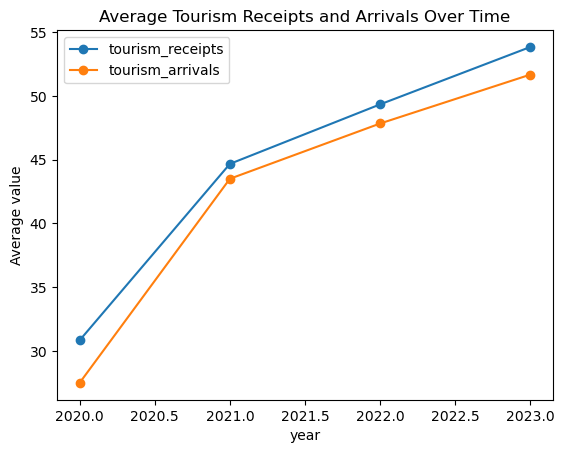

In [14]:
yearly_summary.plot(x="year", y=["tourism_receipts", "tourism_arrivals"], marker="o")
plt.title("Average Tourism Receipts and Arrivals Over Time")
plt.ylabel("Average value")
plt.show()

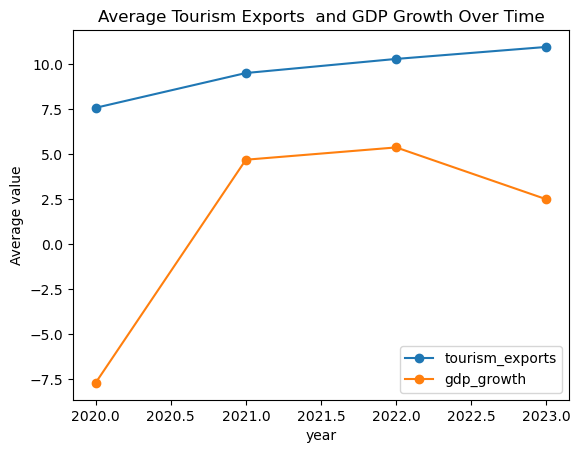

In [15]:
yearly_summary.plot(x="year", y=["tourism_exports", "gdp_growth"], marker = "o")
plt.title("Average Tourism Exports  and GDP Growth Over Time")
plt.ylabel("Average value")
plt.show()



In [17]:
country_summary = df.groupby("country" , as_index=False)[
    ["tourism_receipts","tourism_arrivals", "tourism_exports", "gdp_growth", "unemployment_rate"] ].mean()
country_summary.sort_values("tourism_receipts", ascending=True)

,country,tourism_receipts,tourism_arrivals,tourism_exports,gdp_growth,unemployment_rate
4,Portugal,18.25,18.25,5.30,1.400,6.575
2,Greece,23.25,23.25,6.40,1.500,14.450
3,Italy,46.00,44.00,9.80,0.575,9.225
1,Germany,49.50,49.50,10.70,1.500,3.925
0,France,58.00,58.00,11.95,1.050,7.500
5,Spain,73.00,62.75,13.30,1.200,13.975


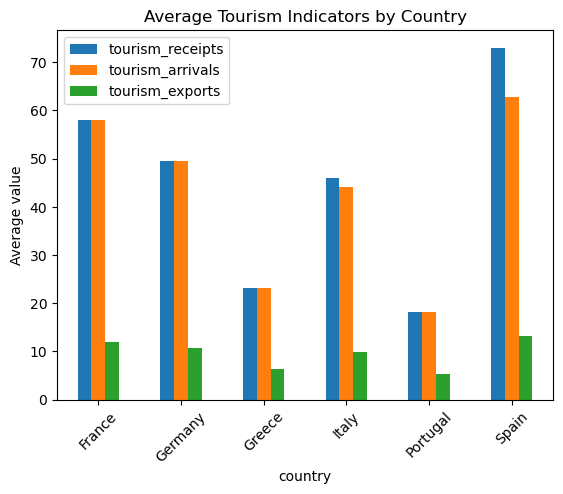

In [18]:
country_summary.plot(
    x="country",
    y=["tourism_receipts", "tourism_arrivals", "tourism_exports"],
    kind="bar"
)
plt.title("Average Tourism Indicators by Country")
plt.ylabel("Average value")
plt.xticks(rotation=45)
plt.show()

In [20]:
corr_matrix = df[["tourism_receipts", "tourism_arrivals", "tourism_exports" ,"gdp_growth" ,"unemployment_rate","inflation_rate"
]] .corr()

corr_matrix
                

,tourism_receipts,tourism_arrivals,tourism_exports,gdp_growth,unemployment_rate,inflation_rate
tourism_receipts,1.000000,0.983397,0.989124,0.317370,0.011682,0.334023
tourism_arrivals,0.983397,1.000000,0.988946,0.392943,-0.095427,0.392618
tourism_exports,0.989124,0.988946,1.000000,0.313642,-0.045440,0.346364
gdp_growth,0.317370,0.392943,0.313642,1.000000,-0.133459,0.681733
unemployment_rate,0.011682,-0.095427,-0.045440,-0.133459,1.000000,-0.177282
inflation_rate,0.334023,0.392618,0.346364,0.681733,-0.177282,1.000000


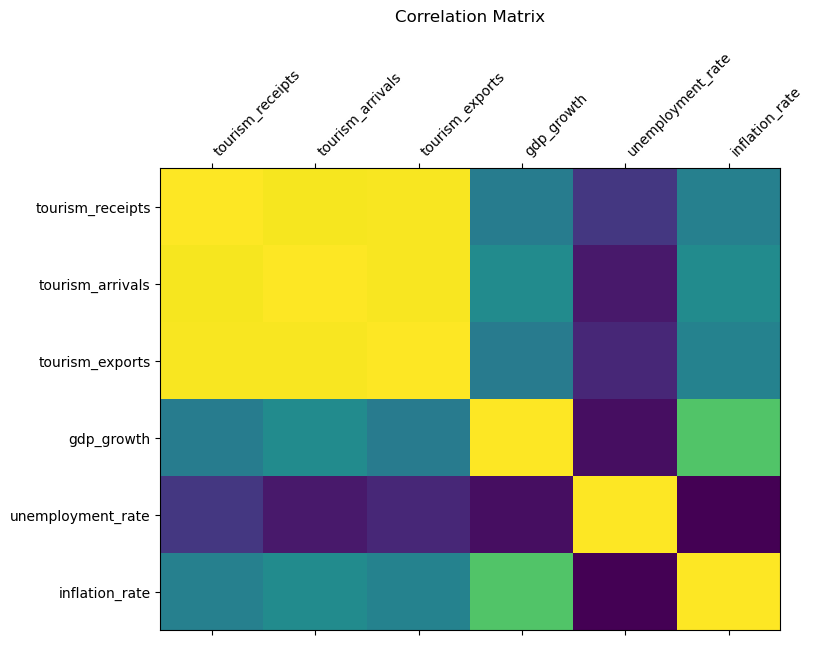

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(corr_matrix, aspect = "auto")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="left")
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix" , pad=20)
plt.show()

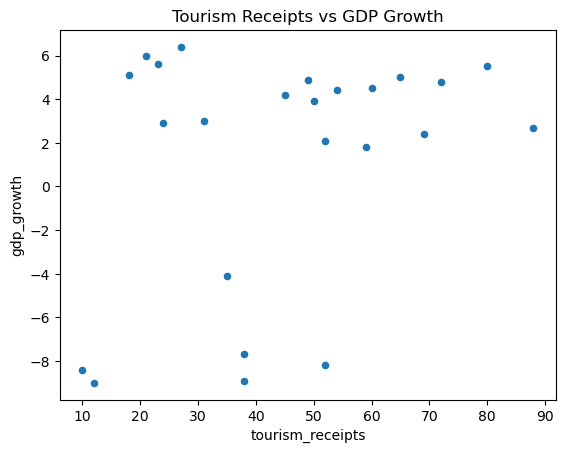

In [22]:
df.plot(x="tourism_receipts", y="gdp_growth", kind= "scatter")
plt.title("Tourism Receipts vs GDP Growth")
plt.show()

In [23]:
pivot_receipts = df.pivot(index ="year", columns="country", values="tourism_receipts")
pivot_receipts

country,France,Germany,Greece,Italy,Portugal,Spain
year,,,,,,
2020,38,35,12,38,10,52
2021,60,50,23,45,18,72
2022,65,54,27,49,21,80
2023,69,59,31,52,24,88


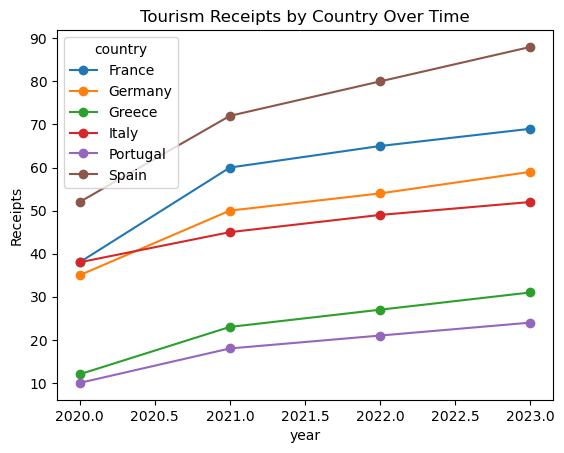

In [24]:
pivot_receipts.plot(marker="o")
plt.title("Tourism Receipts by Country Over Time")
plt.ylabel("Receipts")
plt.show()

## Insights
* Tourism receipts and arrivals show a generally increasing trend over time.
* There appears to be positive relationship between tourism activity and GDP growth.
* Inflation and unemployment do not show a strong  direct relationship with tourism indicators.
* The dataset is clean with no missing values, which makes it reliable for analysis.
  Overall, tourism seems to contribute positively to economic performance.